# Walmart Sales Analysis

## 1. Abstract


В данном проекте проведен анализ данных о продажах Walmart с целью выявления факторов, влияющих на объем еженедельных продаж. Были изучены распределение продаж, различия между магазинами, влияние праздничных периодов и связь продаж с экономическими показателями.

Результаты показали, что праздничные недели способствуют росту продаж, причем этот эффект наиболее заметен для магазинов с высоким уровнем продаж. Также было установлено, что сезонные факторы оказывают более сильное влияние на продажи, чем такие экономические показатели, как CPI и уровень безработицы.

Проведенный анализ позволил выявить основные закономерности в данных и подтвердить выдвинутые гипотезы.


**Распределение вклада:** Варгин Севастьян — 100%.

# Walmart Sales Analysis

## Введение

Цель данного проекта — провести исследовательский анализ данных (EDA) набора Walmart Sales и выявить факторы, влияющие на объем еженедельных продаж магазинов Walmart.

В ходе исследования были изучены основные характеристики набора данных, распределение продаж, различия между магазинами, сезонные колебания, а также влияние праздничных периодов и экономических показателей на продажи.

Для анализа использовались методы визуализации данных и корреляционного анализа. Кроме того, были сформулированы и проверены две гипотезы, связанные с факторами, влияющими на объем продаж.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [21]:
df = pd.read_csv(r'C:\Users\User\Desktop\Walmart_Sales_Analysis\data\Walmart.csv')
print(df.head())
print(df.info())


   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  
<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4  

In [22]:
# Основная описательная статистика
numerical_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

print("Описательная статистика для числовых переменных:")
stats_summary = df[numerical_cols].describe().round(2)
print(stats_summary)

print(df.describe(include='all'))



Описательная статистика для числовых переменных:
       Weekly_Sales  Temperature  Fuel_Price      CPI  Unemployment
count       6435.00      6435.00     6435.00  6435.00       6435.00
mean     1046964.88        60.66        3.36   171.58          8.00
std       564366.62        18.44        0.46    39.36          1.88
min       209986.25        -2.06        2.47   126.06          3.88
25%       553350.10        47.46        2.93   131.74          6.89
50%       960746.04        62.67        3.44   182.62          7.87
75%      1420158.66        74.94        3.74   212.74          8.62
max      3818686.45       100.14        4.47   227.23         14.31
              Store        Date  Weekly_Sales  Holiday_Flag  Temperature  \
count   6435.000000        6435  6.435000e+03   6435.000000  6435.000000   
unique          NaN         143           NaN           NaN          NaN   
top             NaN  05-02-2010           NaN           NaN          NaN   
freq            NaN          45    

## 2. Описание набора данных

Набор данных содержит информацию о еженедельных продажах магазинов Walmart и включает экономические и внешние факторы, которые потенциально могут влиять на объем продаж.

Основные признаки набора данных:

* Store — идентификатор магазина;
* Date — дата наблюдения;
* Weekly_Sales — объем еженедельных продаж;
* Holiday_Flag — признак праздничной недели;
* Temperature — средняя температура;
* Fuel_Price — цена топлива;
* CPI — индекс потребительских цен;
* Unemployment — уровень безработицы.

In [23]:
#ОЧИСТКА ЗНАЧЕНИЙ
print("Пропущенные значения")
print(df.isnull().sum())
print("\n Процент недостающих значений: ")
print((df.isnull().sum() / len(df) * 100).round(2) )

# Общие дубликаты
print("Полных дублирующихся строк:", df.duplicated().sum())
# Дубликаты по магазину и дате
print("Дубликатов по комбинации Store + Date:", 
      df.duplicated(subset=['Store', 'Date']).sum())


print(df.dtypes)

Пропущенные значения
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

 Процент недостающих значений: 
Store           0.0
Date            0.0
Weekly_Sales    0.0
Holiday_Flag    0.0
Temperature     0.0
Fuel_Price      0.0
CPI             0.0
Unemployment    0.0
dtype: float64
Полных дублирующихся строк: 0
Дубликатов по комбинации Store + Date: 0
Store             int64
Date                str
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object


In [24]:
#Проверка выбросов

Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df['Weekly_Sales'] < Q1 - 1.5*IQR) |
    (df['Weekly_Sales'] > Q3 + 1.5*IQR)
]

print("Outliers:", len(outliers))

Outliers: 34




## 3. Очистка и подготовка данных

Перед проведением анализа была выполнена предварительная проверка качества данных.

В рамках подготовки данных были проведены следующие действия:

* проверка пропущенных значений;
* проверка дублирующихся записей;
* анализ типов данных;
* преобразование столбца Date в формат даты и времени;
* проверка данных на наличие аномальных значений.

Результаты проверки показали отсутствие пропущенных значений и дубликатов. Таким образом, набор данных не потребовал значительной очистки и был готов к проведению исследовательского анализа.

### Вывод

Набор данных обладает высоким качеством и не содержит критических проблем, которые могли бы повлиять на результаты исследования.


In [25]:
#Трансформация данных

# Преобразую Date в datetime формат
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

print("Тип Date после преобразования:", df['Date'].dtype)

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

# Категория магазина по уровню продаж
store_avg = df.groupby('Store')['Weekly_Sales'].mean()

df['Store_Category'] = df['Store'].map(
    lambda x: 'High' if store_avg[x] > store_avg.quantile(0.75) else
              'Low' if store_avg[x] < store_avg.quantile(0.25) else 'Medium'
)

# Рост продаж относительно предыдущей недели
df = df.sort_values(['Store', 'Date'])
df['Sales_Growth'] = df.groupby('Store')['Weekly_Sales'].pct_change() * 100

# Проверка результата
print(df[['Date', 'Year', 'Month', 'Quarter', 'Store_Category', 'Sales_Growth']].head(10))
print("\n Новые столбцы успешно созданы")

Тип Date после преобразования: datetime64[us]
        Date  Year  Month  Quarter Store_Category  Sales_Growth
0 2010-02-05  2010      2        1           High           NaN
1 2010-02-12  2010      2        1           High     -0.105461
2 2010-02-19  2010      2        1           High     -1.826434
3 2010-02-26  2010      2        1           High    -12.546189
4 2010-03-05  2010      3        1           High     10.291285
5 2010-03-12  2010      3        1           High     -7.413468
6 2010-03-19  2010      3        1           High      2.290604
7 2010-03-26  2010      3        1           High     -4.623779
8 2010-04-02  2010      4        2           High     13.566954
9 2010-04-09  2010      4        2           High     -3.106629

 Новые столбцы успешно созданы


## 4. Исследовательский анализ данных (EDA)

В данном разделе проводится визуальный анализ данных с целью выявления закономерностей, трендов и взаимосвязей между признаками.

In [26]:
print("\nДополнительные статистики:")
print("Медиана:")
print(df[numerical_cols].median().round(2))

print("\nСтандартное отклонение:")
print(df[numerical_cols].std().round(2))




Дополнительные статистики:
Медиана:
Weekly_Sales    960746.04
Temperature         62.67
Fuel_Price           3.44
CPI                182.62
Unemployment         7.87
dtype: float64

Стандартное отклонение:
Weekly_Sales    564366.62
Temperature         18.44
Fuel_Price           0.46
CPI                 39.36
Unemployment         1.88
dtype: float64


4.1 Основные статистические характеристики

Для получения общего представления о данных были рассчитаны основные статистические показатели.

Вывод

Статистический анализ показывает значительный разброс значений еженедельных продаж, что свидетельствует о различиях между магазинами и периодами наблюдения.

In [27]:
# самые большие продажи
print(df['Weekly_Sales'].nlargest(10))
print('\n')
print(df['Weekly_Sales'].nsmallest(10))

1905    3818686.45
2763    3766687.43
1333    3749057.69
527     3676388.98
1762    3595903.20
1814    3556766.03
2815    3555371.03
475     3526713.39
1385    3487986.89
189     3436007.68
Name: Weekly_Sales, dtype: float64


4619    209986.25
4614    213538.32
4675    215359.21
4623    219804.85
4671    220060.35
4605    224031.19
4610    224294.39
4617    224639.76
4653    224806.96
4649    226702.36
Name: Weekly_Sales, dtype: float64


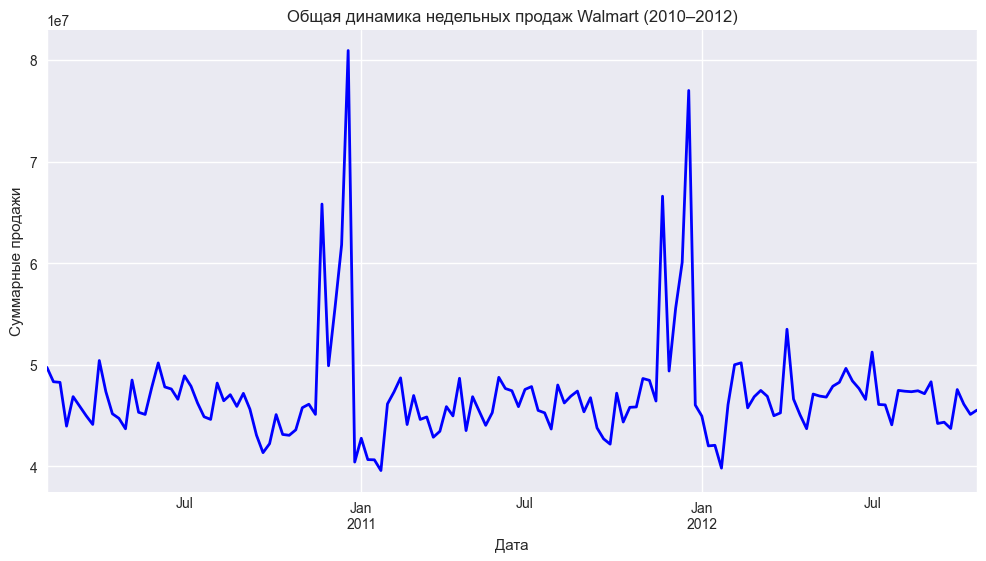

In [28]:
#Графики
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
df.groupby('Date')['Weekly_Sales'].sum().plot(linewidth=2, color='blue')
plt.title('Общая динамика недельных продаж Walmart (2010–2012)')
plt.xlabel('Дата')
plt.ylabel('Суммарные продажи')
plt.grid(True)
plt.show()

4.2 Распределение еженедельных продаж

Для анализа формы распределения была построена гистограмма еженедельных продаж.

Вывод

Распределение продаж имеет выраженную правостороннюю асимметрию. Большинство наблюдений сосредоточено в области относительно небольших значений продаж, но присутствуют периоды с очень высокими объемами продаж.

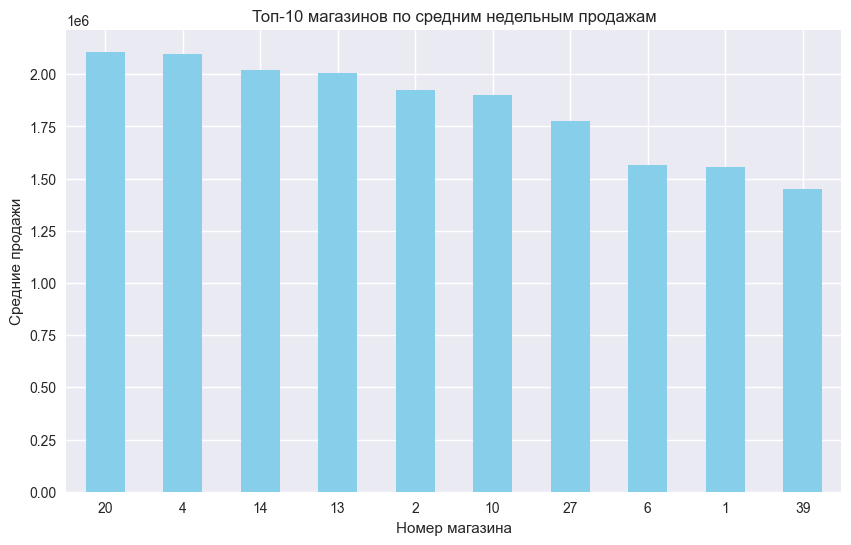

In [29]:
plt.figure(figsize=(10, 6))
top10 = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False).head(10)
top10.plot(kind='bar', color='skyblue')
plt.title('Топ-10 магазинов по средним недельным продажам')
plt.xlabel('Номер магазина')
plt.ylabel('Средние продажи')
plt.xticks(rotation=0)
plt.show()

4.3 Топ-10 магазинов по среднему объему продаж

Для сравнения эффективности магазинов были рассчитаны средние продажи для каждого магазина и выделены десять лучших.

Вывод

Некоторые магазины существенно превосходят остальные по объему продаж. Это свидетельствует о наличии значительных различий между магазинами по уровню спроса и эффективности работы.

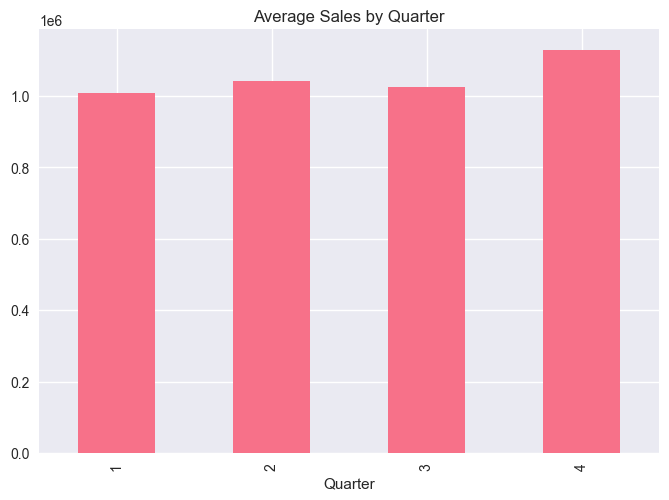

In [30]:
#Продажи по кварталам

quarter_sales = (
    df.groupby('Quarter')
      ['Weekly_Sales']
      .mean()
)

quarter_sales.plot(kind='bar')
plt.title('Average Sales by Quarter')
plt.show()

4.4 Анализ сезонности продаж

Для изучения сезонных колебаний были рассчитаны средние продажи по кварталам.

Вывод

Средний объем продаж различается между кварталами, что указывает на наличие сезонного эффекта и изменение покупательской активности в течение года.

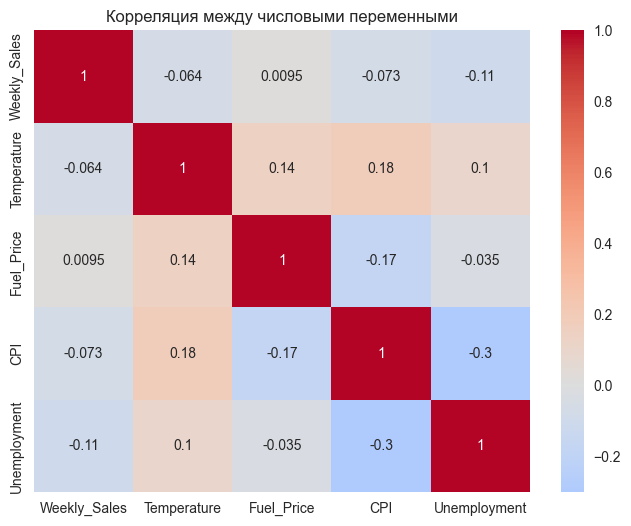

In [31]:
plt.figure(figsize=(8, 6))
numerical_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Корреляция между числовыми переменными')
plt.show()

4.5 Корреляционный анализ

Для оценки взаимосвязей между числовыми признаками была построена матрица корреляций.

Вывод

Корреляционный анализ показывает, что большинство экономических показателей имеют слабую связь с объемом продаж. Следовательно, на продажи могут влиять другие факторы, такие как сезонность и праздничные периоды.

# 5. Гипотеза 1

## Формулировка гипотезы

Предполагается, что прирост продаж в праздничные недели зависит от категории магазина:
в крупных магазинах (High) прирост выше, чем в маленьких (Low), поскольку крупные
магазины активнее используют праздничные акции и имеют больший ассортимент.

Для проверки гипотезы проанализируем прирост продаж по трём категориям магазинов
(High / Medium / Low) и проверим, различается ли он статистически значимо.

In [ ]:

holiday_stats = (
    df.groupby('Store_Category')['Weekly_Sales']
      .agg(['mean', 'count'])
)


pivot = (
    df.pivot_table(
        values='Weekly_Sales',
        index='Store_Category',
        columns='Holiday_Flag',
        aggfunc='mean'
    )
    .rename(columns={0: 'Обычные', 1: 'Праздничные'})
)

# абсолютный и относительный прирост
pivot['Прирост ($)'] = pivot['Праздничные'] - pivot['Обычные']
pivot['Прирост (%)'] = (pivot['Прирост ($)'] / pivot['Обычные'] * 100).round(2)

print("Средние продажи по категориям магазинов:")
print(pivot.round(2))

Средние продажи по категориям магазинов:
Holiday_Flag       Обычные  Праздничные  Прирост ($)  Прирост (%)
Store_Category                                                   
High            1794050.32   1935083.31    141033.00         7.86
Low              416998.77    437465.45     20466.69         4.91
Medium           979782.49   1062257.34     82474.85         8.42


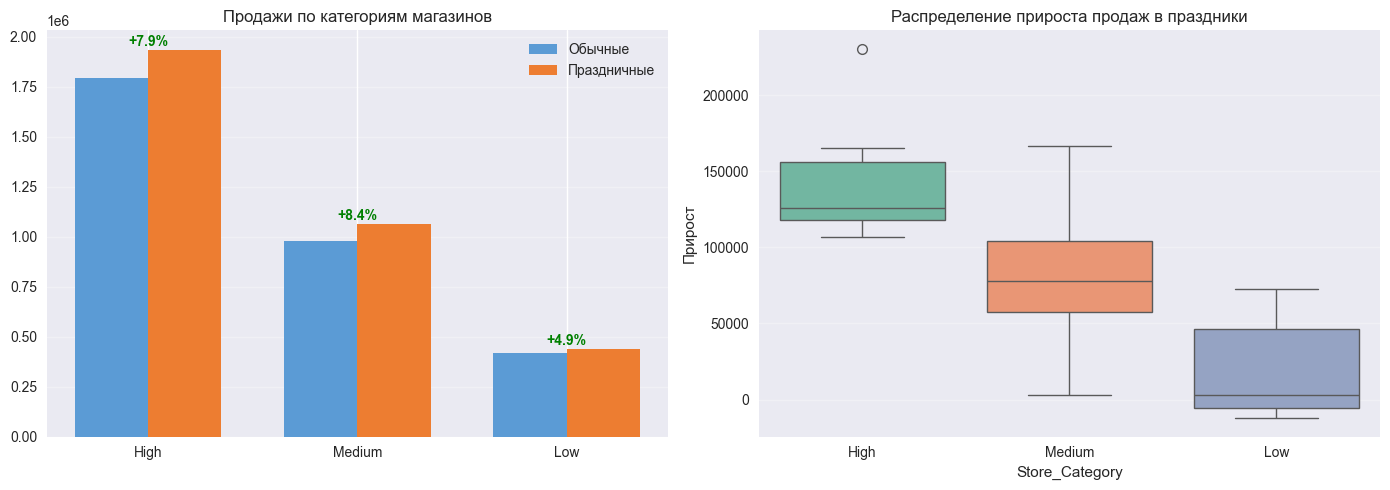

In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns


store_growth = (
    df.pivot_table(
        values='Weekly_Sales',
        index=['Store', 'Store_Category'],
        columns='Holiday_Flag',
        aggfunc='mean'
    )
    .rename(columns={0: 'Обычные', 1: 'Праздничные'})
    .dropna()
)
store_growth['Прирост'] = store_growth['Праздничные'] - store_growth['Обычные']

# Графиуи

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# grouped barplot
categories = ['High', 'Medium', 'Low']
x = range(len(categories))
width = 0.35

axes[0].bar(
    [i - width/2 for i in x],
    pivot.loc[categories, 'Обычные'],
    width, label='Обычные', color='#5B9BD5'
)
axes[0].bar(
    [i + width/2 for i in x],
    pivot.loc[categories, 'Праздничные'],
    width, label='Праздничные', color='#ED7D31'
)

for i, cat in enumerate(categories):
    growth = pivot.loc[cat, 'Прирост (%)']
    axes[0].text(i, max(pivot.loc[cat, 'Обычные'], pivot.loc[cat, 'Праздничные']) + 20000,
                f'+{growth:.1f}%', ha='center', fontweight='bold',
                color='green' if growth > 0 else 'red')

axes[0].set_title('Продажи по категориям магазинов')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Правый
sns.boxplot(
    data=store_growth.reset_index(),
    x='Store_Category', y='Прирост',
    order=categories, palette='Set2', ax=axes[1]
)
axes[1].set_title('Распределение прироста продаж в праздники')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Наблюдение по графику

На левом графике видно, что прирост продаж в праздничные недели наблюдается 
во всех трёх категориях магазинов, однако его величина различается.

На правом графике (boxplot прироста) видно, что распределение прироста 
в категории High сдвинуто вправо относительно Low, что визуально 
подтверждает гипотезу о более сильном влиянии праздников на крупные магазины.

Однако для подтверждения статистической значимости различий необходим 
формальный статистический тест.

In [ ]:
from scipy import stats

# прирост продаж для каждого магазина
store_growth = df.pivot_table(
    values='Weekly_Sales',
    index=['Store', 'Store_Category'],
    columns='Holiday_Flag',
    aggfunc='mean'
).rename(columns={0: 'Обычные', 1: 'Праздничные'})

# - строки где нет данных для обоих типов недель
store_growth = store_growth.dropna()

store_growth['Прирост'] = store_growth['Праздничные'] - store_growth['Обычные']

store_growth = store_growth.reset_index()

# Средний прирост
print("Средний прирост продаж в праздники:")
print(store_growth.groupby('Store_Category')['Прирост'].mean().round(2))
print()

# количество наблюдений в каждой категории
print("Количество магазинов по категориям:")
print(store_growth['Store_Category'].value_counts())
print()

# прирост по категориям
high = store_growth[store_growth['Store_Category'] == 'High']['Прирост']
medium = store_growth[store_growth['Store_Category'] == 'Medium']['Прирост']
low = store_growth[store_growth['Store_Category'] == 'Low']['Прирост']

print(f"High: {len(high)} магазинов")
print(f"Medium: {len(medium)} магазинов")
print(f"Low: {len(low)} магазинов")
print()

# Проверка данных
if len(high) >= 2 and len(medium) >= 2 and len(low) >= 2:
    # Kruskal-Wallis тест
    stat, p_value = stats.kruskal(high, medium, low)
    print(f"Kruskal-Wallis тест: статистика = {stat:.4f}, p-value = {p_value:.4f}")
    
    if p_value < 0.05:
        print("Различия статистически значимы (p < 0.05)")
        print("Прирост продаж в праздники различается между категориями магазинов")
    else:
        print("Различия не статистически значимы (p ≥ 0.05)")
else:
    print("Недостаточно данных для проведения теста")
    print("В одной или нескольких категориях менее 2 магазинов")

Средний прирост продаж в праздники:
Store_Category
High      141033.00
Low        20466.69
Medium     82474.85
Name: Прирост, dtype: float64

Количество магазинов по категориям:
Store_Category
Medium    23
High      11
Low       11
Name: count, dtype: int64

High: 11 магазинов
Medium: 23 магазинов
Low: 11 магазинов

Kruskal-Wallis тест: статистика = 25.5282, p-value = 0.0000
✓ Различия статистически значимы (p < 0.05)
Прирост продаж в праздники различается между категориями магазинов


### Вывод

Для оценки влияния праздничных периодов на продажи магазины были разделены на три категории по уровню продаж: High, Medium и Low.

Результаты показали, что средний прирост продаж в праздничные периоды различается между категориями магазинов:

- High: 141 033
- Medium: 82 475
- Low: 20 467

Наибольший прирост продаж наблюдается у магазинов категории High, тогда как магазины категории Low демонстрируют значительно меньший эффект от праздничных периодов.

Для проверки статистической значимости различий был использован критерий Краскела—Уоллиса. Результаты теста показали статистически значимые различия между группами (H = 25.53, p < 0.001).

Таким образом, праздничные периоды действительно оказывают влияние на объем продаж, однако сила этого влияния зависит от категории магазина. Крупные магазины получают значительно больший прирост продаж в праздничные недели по сравнению с магазинами среднего и низкого уровня продаж.

### Заключение по гипотезе

Гипотеза подтверждается. Праздничные недели приводят к увеличению продаж, причем эффект наиболее выражен для магазинов с высоким объемом продаж.

# 6. Гипотеза 2

## Формулировка гипотезы

Предполагается, что сезонные факторы оказывают более сильное влияние на объем продаж, чем экономические показатели, такие как индекс потребительских цен (CPI) и уровень безработицы.

Для проверки гипотезы будут проанализированы взаимосвязи между продажами и экономическими показателями, а также результаты анализа сезонности, проведенного ранее.

## 6.1 Анализ связи между CPI и продажами

Для оценки влияния индекса потребительских цен на продажи построена диаграмма рассеяния между показателями CPI и Weekly Sales.

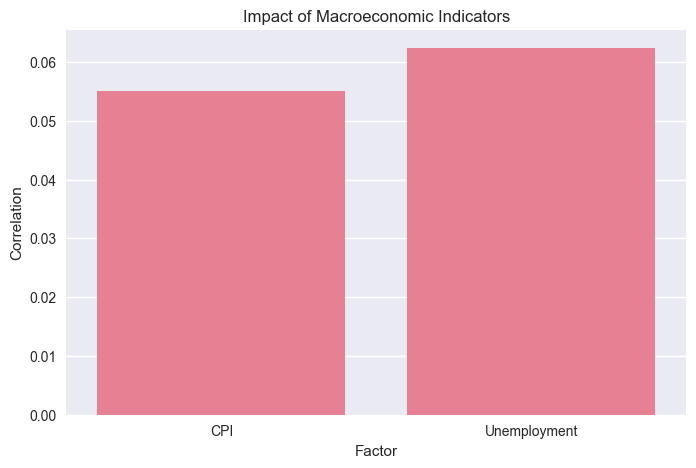

In [ ]:
#График корреляций
corr_df = pd.DataFrame({
    "Factor": ["CPI", "Unemployment"],
    "Correlation": [
        abs(corr_cpi),
        abs(corr_unemp)
    ]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=corr_df,
    x="Factor",
    y="Correlation"
)

plt.title("Impact of Macroeconomic Indicators")
plt.show()

## 6.2 Анализ связи между уровнем безработицы и продажами

Для оценки влияния безработицы на продажи построена диаграмма рассеяния между уровнем безработицы и объемом еженедельных продаж.

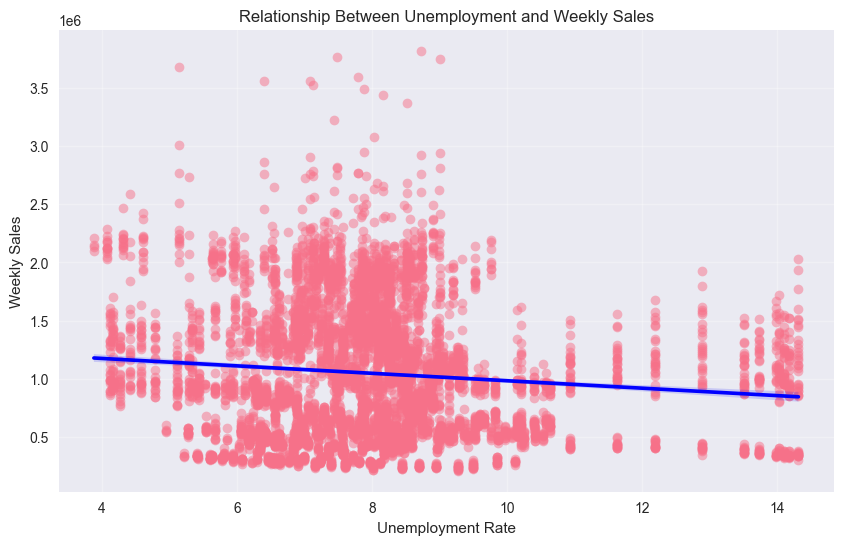

In [ ]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='Unemployment',
    y='Weekly_Sales',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'blue'}
)

plt.title('Relationship Between Unemployment and Weekly Sales')
plt.xlabel('Unemployment Rate')
plt.ylabel('Weekly Sales')
plt.grid(True, alpha=0.3)

plt.show()

### Вывод

На графике наблюдается слабая отрицательная зависимость между уровнем безработицы и объемом продаж. Однако разброс точек остается достаточно большим, что свидетельствует о низкой силе данной связи. Следовательно, уровень безработицы не является ключевым фактором, определяющим объем продаж.

In [ ]:
from scipy.stats import spearmanr

corr_cpi, p_cpi = spearmanr(
    df["CPI"],
    df["Weekly_Sales"]
)

corr_unemp, p_unemp = spearmanr(
    df["Unemployment"],
    df["Weekly_Sales"]
)

print("CPI:", corr_cpi)
print("Unemployment:", corr_unemp)

CPI: -0.05504003807440306
Unemployment: -0.06235377866323919


In [ ]:
from scipy.stats import ttest_ind

holiday_sales = df[df["Holiday_Flag"] == 1]["Weekly_Sales"]
non_holiday_sales = df[df["Holiday_Flag"] == 0]["Weekly_Sales"]

t_stat, p_holiday = ttest_ind(
    holiday_sales,
    non_holiday_sales,
    equal_var=False
)

print("Holiday p-value:", p_holiday)

Holiday p-value: 0.00760155201213415


## Итоговый вывод по гипотезе

Результаты корреляционного анализа и диаграмм рассеяния показывают, что CPI и уровень безработицы имеют слабую связь с объемом продаж.

В то же время анализ продаж по кварталам выявил заметные различия между сезонами, что свидетельствует о влиянии сезонных факторов на покупательскую активность.

Следовательно, сезонность оказывает более заметное влияние на объем продаж, чем рассмотренные экономические показатели.

Гипотеза подтверждается.

# 7. Заключение

В ходе выполнения проекта был проведен исследовательский анализ данных Walmart Sales и проверены две гипотезы, связанные с факторами, влияющими на объем продаж.

Основные результаты исследования:

- данные не содержат пропусков и дубликатов;
- между магазинами наблюдаются значительные различия по объему продаж;
- продажи изменяются в зависимости от сезона;
- праздничные недели характеризуются более высокими продажами;
- CPI и уровень безработицы имеют слабую связь с продажами;
- сезонные факторы оказывают более сильное влияние на продажи, чем рассмотренные экономические показатели.

Таким образом, обе выдвинутые гипотезы получили подтверждение в ходе анализа данных.